In [1]:

import math
import numpy
import torch    # pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
import graphviz
import matplotlib

%matplotlib inline
numpy.set_printoptions(suppress=True)

In [2]:
def trace_torch(root):
    nodes, edges = set(), set()

    def build(var):
        if var not in nodes:
            nodes.add(var)
            if var.grad_fn is not None:
                for child, _ in var.grad_fn.next_functions:
                    if child is not None:
                        # Find the tensor that corresponds to this grad_fn
                        child_tensor = None
                        for n in nodes:
                            if n.grad_fn == child:
                                child_tensor = n
                                break
                        if child_tensor is None:
                            # Create a dummy wrapper to traverse further
                            child_tensor = _find_tensor_for_grad_fn(child)
                        if child_tensor is not None:
                            edges.add((child_tensor, var))
                            build(child_tensor)

    build(root)
    return nodes, edges


def _find_tensor_for_grad_fn(grad_fn):
    """Reconstruct a minimal tensor-like wrapper for internal grad_fn nodes."""
    return None  # Fallback: we'll use a grad_fn-based approach instead


def trace_torch_ops(root):
    """Trace the computation graph via grad_fn objects."""
    nodes = set()  # grad_fn or 'AccumulateGrad' leaf nodes
    edges = set()

    def build(fn):
        if fn not in nodes:
            nodes.add(fn)
            for child, _ in fn.next_functions:
                if child is not None:
                    edges.add((child, fn))
                    build(child)

    if root.grad_fn is not None:
        build(root.grad_fn)
    return nodes, edges


def draw_dot_torch(root, format="svg", rankdir="LR"):
    """
    Visualize the PyTorch autograd computation graph, similar to draw_dot_Value.

    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ["LR", "TB"]

    dot = graphviz.Digraph(format=format, graph_attr={"rankdir": rankdir})

    seen_fns = set()

    def _add_nodes(fn):
        if fn in seen_fns:
            return
        seen_fns.add(fn)

        uid = str(id(fn))

        if hasattr(fn, "variable"):
            # This is an AccumulateGrad node — it holds a leaf tensor
            tensor = fn.variable
            grad_val = tensor.grad.item() if tensor.grad is not None else 0.0
            label = "{ data %.4f | grad %.4f }" % (tensor.data.item(), grad_val)
            dot.node(name=uid, label=label, shape="record")
        else:
            # This is an operation node (e.g., TanhBackward0, AddBackward0, etc.)
            op_name = type(fn).__name__
            dot.node(name=uid, label=op_name, shape="ellipse")

        for child, _ in fn.next_functions:
            if child is not None:
                _add_nodes(child)
                dot.edge(str(id(child)), uid)

    # Add the output node itself
    if root.grad_fn is not None:
        out_uid = str(id(root))
        # Only access .grad on leaf tensors to avoid UserWarning
        if root.is_leaf:
            grad_val = root.grad.item() if root.grad is not None else 0.0
        elif root.retains_grad and root.grad is not None:
            grad_val = root.grad.item()
        else:
            grad_val = 0.0
        label = "{ output | data %.4f | grad %.4f }" % (root.data.item(), grad_val)
        dot.node(name=out_uid, label=label, shape="record")

        fn_uid = str(id(root.grad_fn))
        _add_nodes(root.grad_fn)
        dot.edge(fn_uid, out_uid)
    else:
        # Leaf tensor with no grad_fn
        out_uid = str(id(root))
        grad_val = root.grad.item() if root.grad is not None else 0.0
        label = "{ data %.4f | grad %.4f }" % (root.data.item(), grad_val)
        dot.node(name=out_uid, label=label, shape="record")

    return dot

In [3]:
print(torch.Tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]))
print(torch.Tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]).shape)
print(torch.Tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]).dtype)
print(torch.Tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]).double().dtype)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])
torch.float32
torch.float64


In [4]:
x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True

x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True

w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double()
b.reals_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())

o.backward()

print("---")
print(f"x1.grad: {x1.grad.item()}")
print(f"x2.grad: {x2.grad.item()}")
print(f"w1.grad: {w1.grad.item()}")
print(f"w2.grad: {w2.grad.item()}")

0.7071066904050358
---
x1.grad: -1.5000003851533106
x2.grad: 0.5000001283844369
w1.grad: 1.0000002567688737
w2.grad: 0.0


In [5]:
print(o)
print(o.item())
print(o.data.item())

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
0.7071066904050358
0.7071066904050358


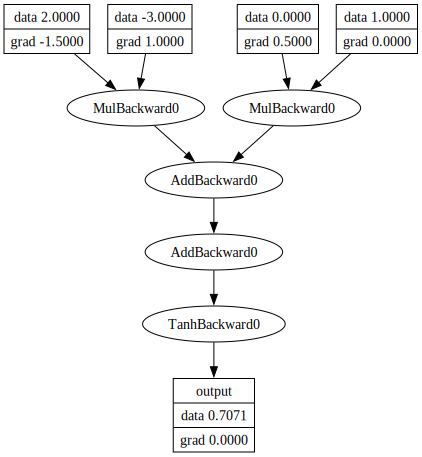

In [7]:
draw_dot_torch(o, rankdir="TB")